# Nama: Senta Fito Situmorang
# NIM:  4222301017
# Kelas: 6A Pagi

In [63]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [64]:
df = pd.read_csv('berat_tinggi.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai berat vs tinggi')

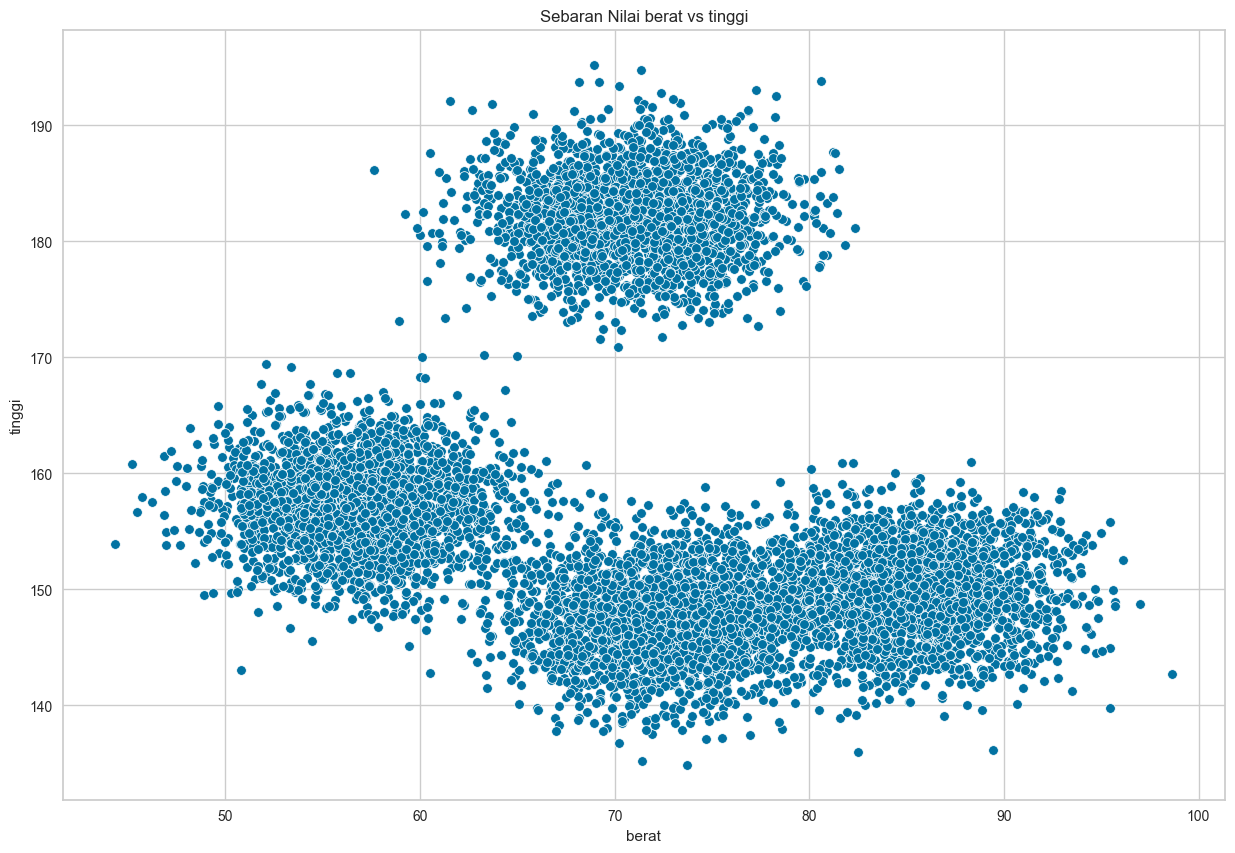

In [65]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')
plt.title('Sebaran Nilai berat vs tinggi')

In [66]:
df.describe()

,tinggi,berat
count,8888.000000,8888.000000
mean,159.125498,71.365302
std,14.258305,10.729120
min,134.881305,44.344643
25%,148.522565,63.557079
50%,153.805704,71.748643
75%,170.365514,79.003827
max,195.232920,98.644868


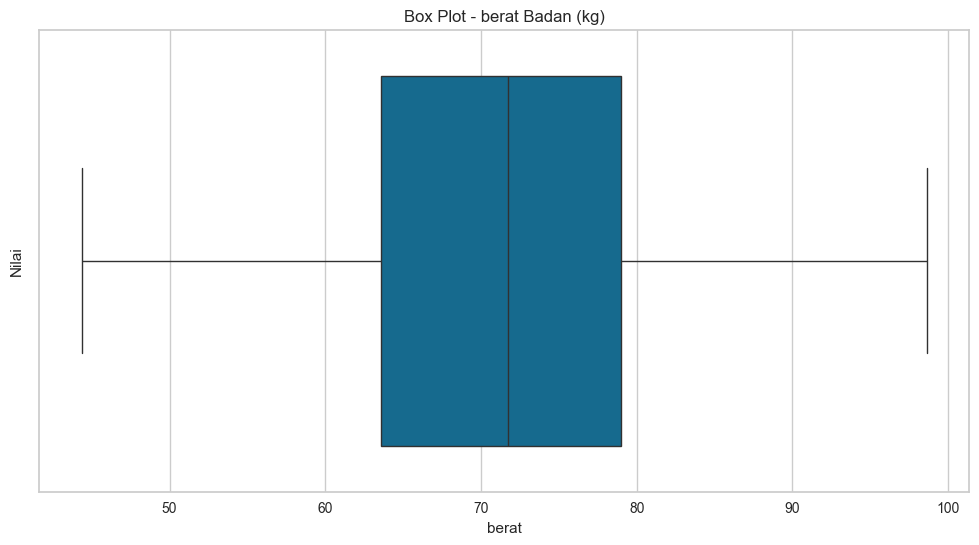

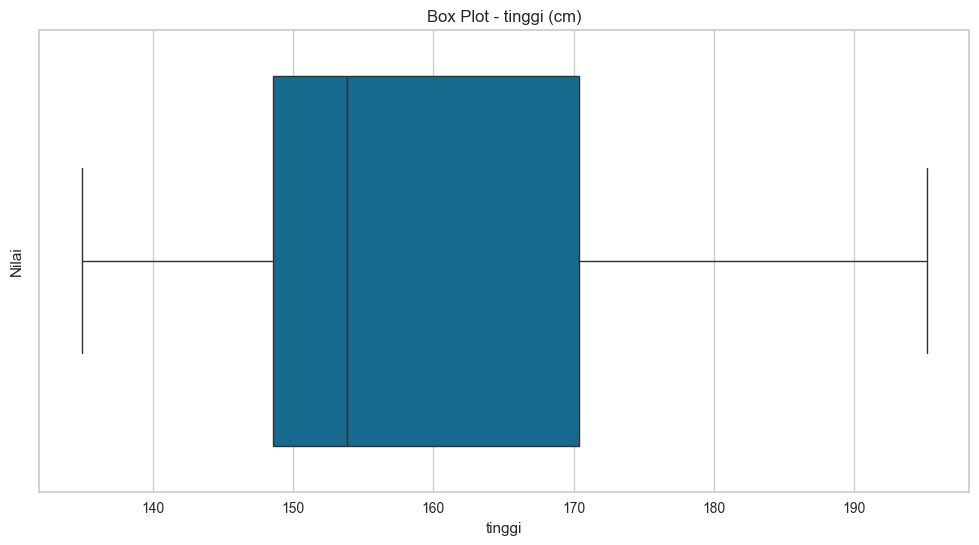

In [67]:
# Looping untuk kolom 'berat' dan 'tinggi'
columns = ['berat', 'tinggi']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

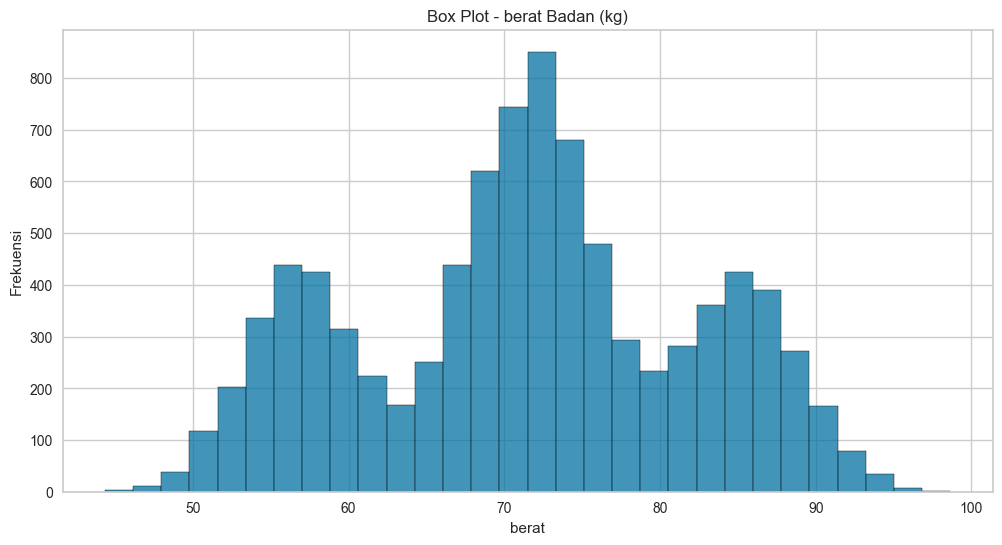

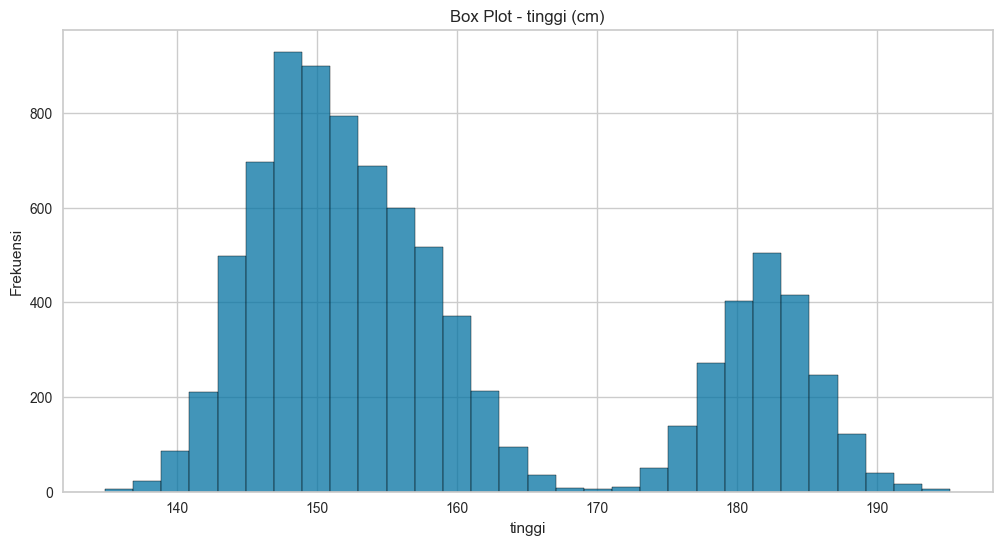

In [68]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [69]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 8888
Dataframe dimension after duplication drop 8888


dari hasil running program diatas, tidak ada data yg duplikat

In [70]:
fitur_columns = ['berat', 'tinggi']
X = df[fitur_columns].values
y = df['deskripsi'].values #anotator label

In [71]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,berat,tinggi
count,8.888000e+03,8.888000e+03
mean,3.785351e-16,-1.893375e-15
std,1.000056e+00,1.000056e+00
min,-2.518583e+00,-1.700451e+00
25%,-7.278008e-01,-7.436739e-01
50%,3.573103e-02,-3.731224e-01
75%,7.119833e-01,7.883579e-01
max,2.542716e+00,2.532521e+00


In [72]:
X_std

array([[-1.2118229 , -0.07092171],
       [-1.75281897,  0.08546572],
       [-0.87900786,  0.16556767],
       ...,
       [-0.89346332, -0.02015625],
       [-1.6141688 , -0.17762697],
       [ 1.40264032, -0.3111536 ]])

In [73]:
df_scalling

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105
...,...,...
8883,0.329937,1.274490
8884,0.905892,-0.527475
8885,-0.893463,-0.020156
8886,-1.614169,-0.177627


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

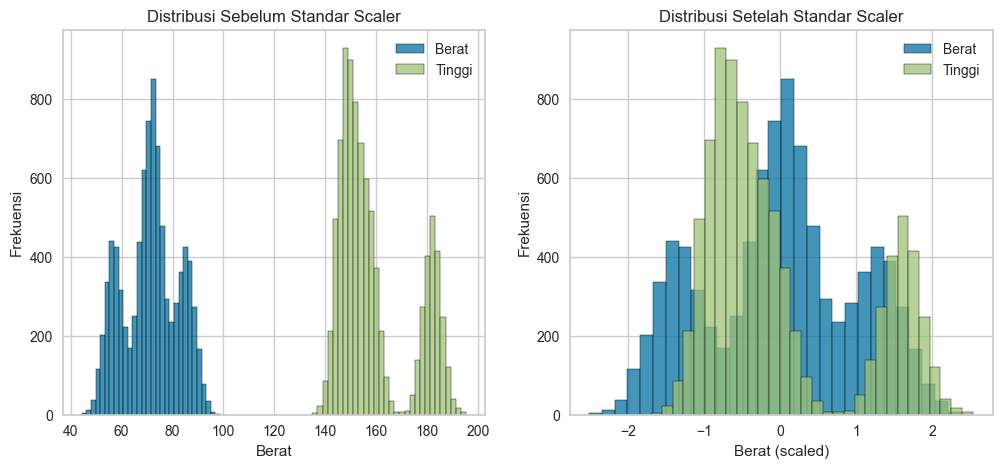

In [74]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
sns.histplot(df['berat'], bins=30, kde=False, ax=ax1)
sns.histplot(df['tinggi'], bins=30, kde=False, ax=ax1)
ax1.set_title('Distribusi Sebelum Standar Scaler')

# Plot distribusi setelah Standar Scaler (Isi dibawah ini)
sns.histplot(df_scalling['berat'], bins=30, kde=False, ax=ax2)
sns.histplot(df_scalling['tinggi'], bins=30, kde=False, ax=ax2)
ax2.set_title('Distribusi Setelah Standar Scaler')

# Set x-labels
ax1.set_xlabel('Berat')
ax2.set_xlabel('Berat (scaled)')
ax1.set_ylabel('Frekuensi')
ax2.set_ylabel('Frekuensi')

# Menampilkan legenda
ax1.legend(['Berat', 'Tinggi'])
ax2.legend(['Berat', 'Tinggi'])

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. berat jadi termapping antara -2 dan 2
2. distribusi terpusat di sekitar 0


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

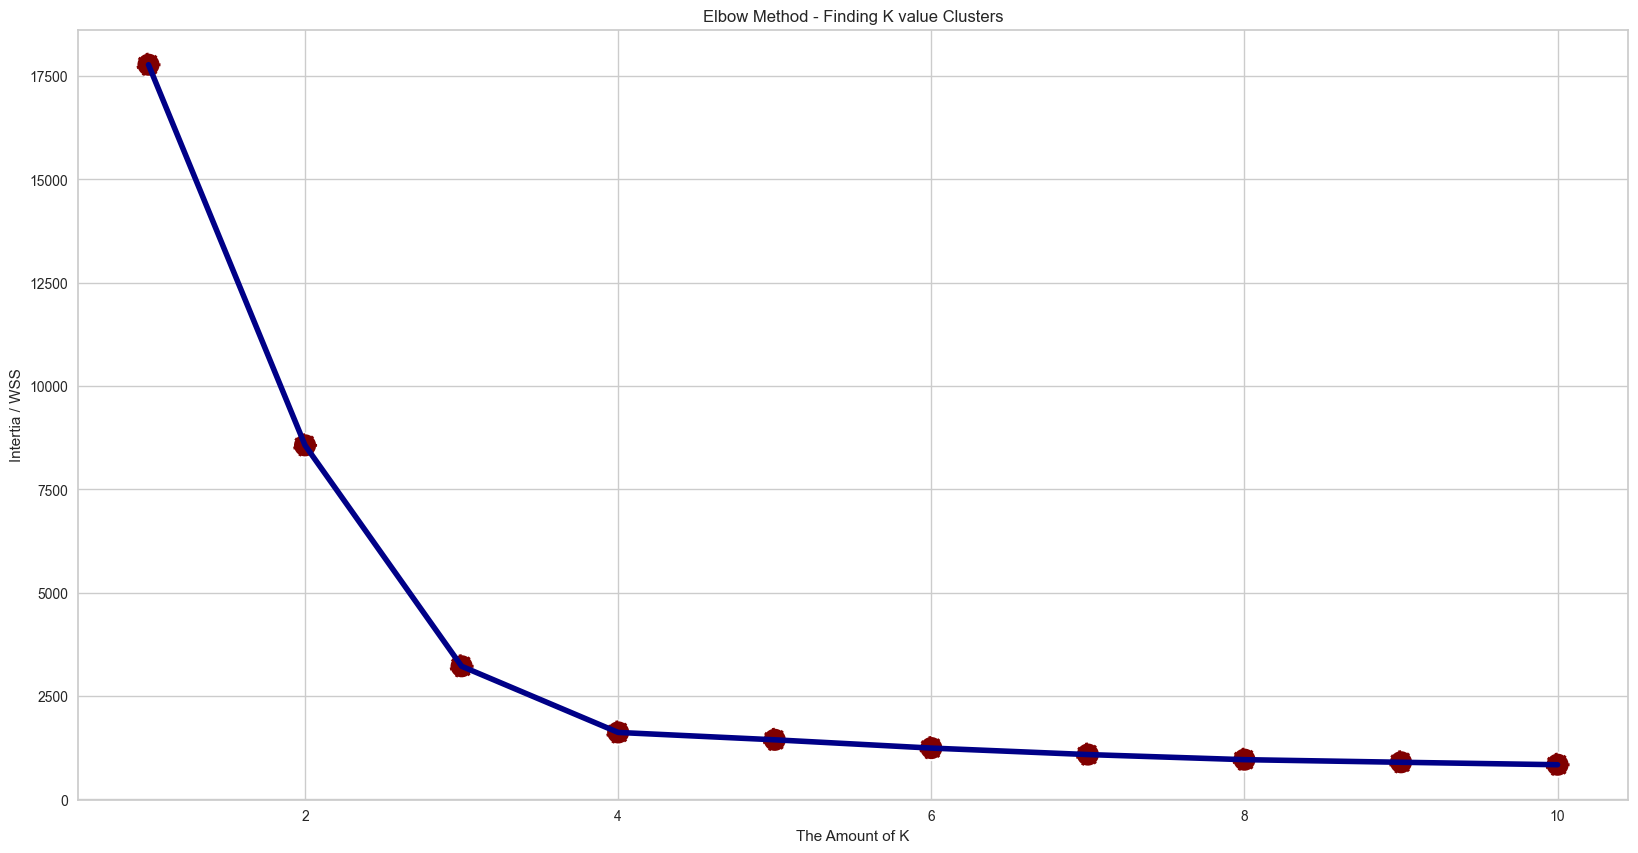

In [75]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [76]:
#Dari hasil diatas elbow nya dipilih pada angka 3,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [77]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [78]:
df

,tinggi,berat,deskripsi,cluster_elbow
0,158.114332,58.364240,Normal,0
1,160.344026,52.560155,Normal,0
2,161.486080,61.934852,Normal,0
3,182.459297,69.042108,Slim,2
4,184.462584,71.341076,Slim,2
...,...,...,...,...
8883,177.296550,74.905033,Slim,2
8884,151.605026,81.084183,Obese,1
8885,158.838120,61.779766,Normal,0
8886,156.592981,54.047666,Normal,0


<Axes: xlabel='berat', ylabel='tinggi'>

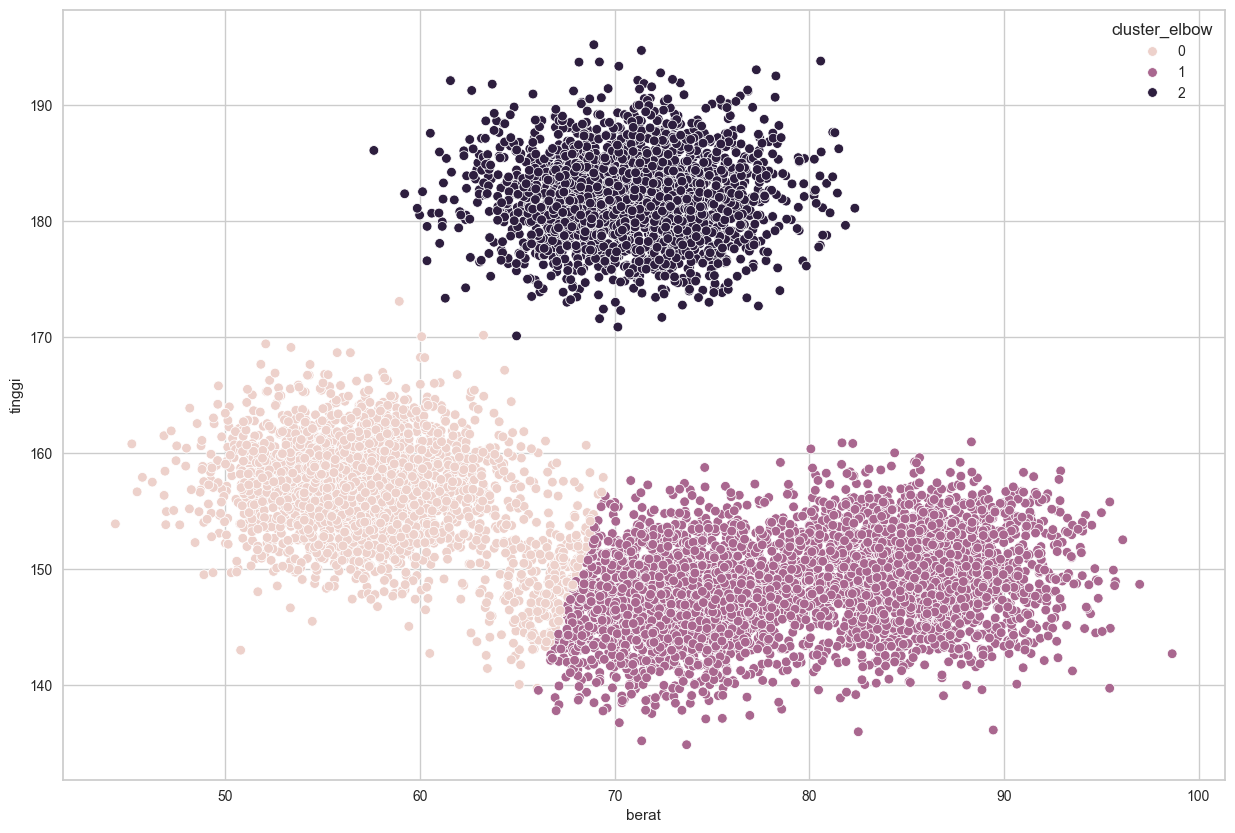

In [79]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

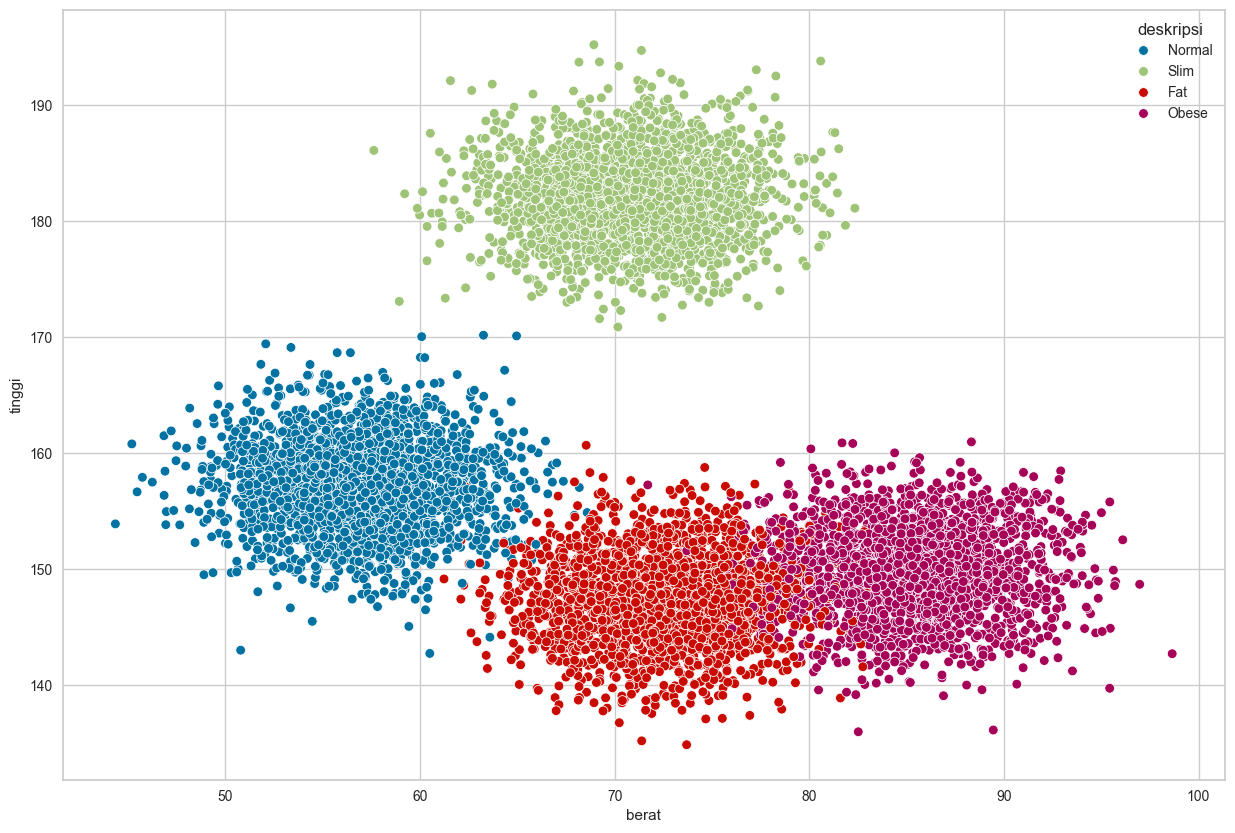

In [80]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',hue='deskripsi')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

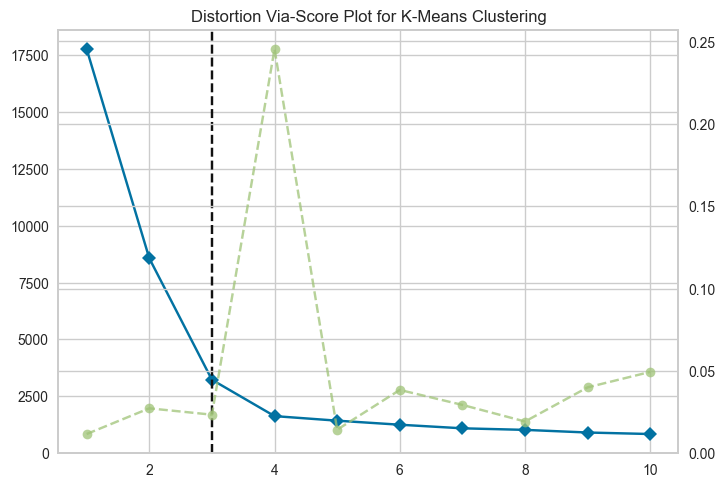

In [81]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [82]:
# Dari hasil diatas K-nya dipilih pada angka 4,
# karena titik distorsinya bertemu pada nilai 4 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=4, random_state=0)
kmeans_via.fit(df_scalling.values)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [83]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [84]:
df

,tinggi,berat,deskripsi,cluster_elbow,cluster_via
0,158.114332,58.364240,Normal,0,0
1,160.344026,52.560155,Normal,0,0
2,161.486080,61.934852,Normal,0,0
3,182.459297,69.042108,Slim,2,2
4,184.462584,71.341076,Slim,2,2
...,...,...,...,...,...
8883,177.296550,74.905033,Slim,2,2
8884,151.605026,81.084183,Obese,1,3
8885,158.838120,61.779766,Normal,0,0
8886,156.592981,54.047666,Normal,0,0


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

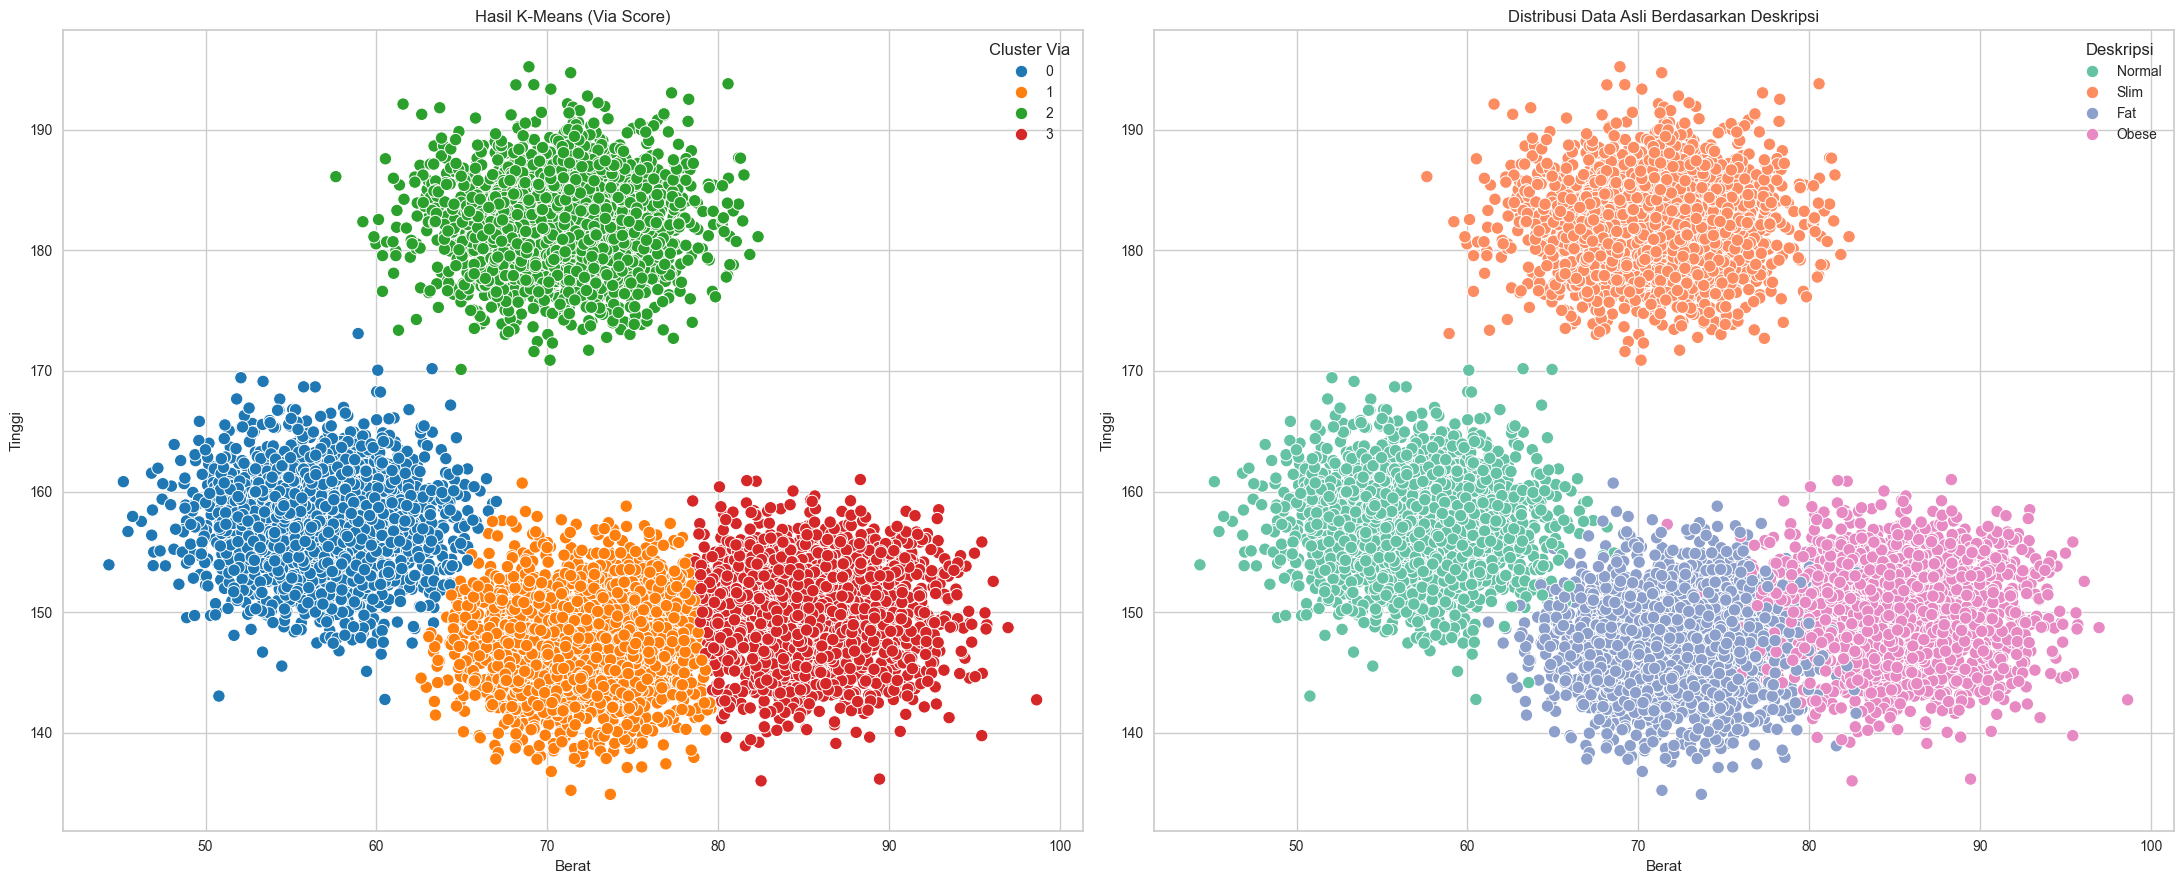

In [85]:
# Lakukan evaluasi setelah dilakukan K-Means
# Bandingkan hasil cluster dengan distribusi data asli
fig, axes = plt.subplots(ncols=2, figsize=(22, 9))

sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='cluster_via',
    palette='tab10',
    s=80,
    ax=axes[0]
)
axes[0].set_title('Hasil K-Means (Via Score)')
axes[0].set_xlabel('Berat')
axes[0].set_ylabel('Tinggi')
axes[0].legend(title='Cluster Via', loc='best')

sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='deskripsi',
    palette='Set2',
    s=80,
    ax=axes[1]
)
axes[1].set_title('Distribusi Data Asli Berdasarkan Deskripsi')
axes[1].set_xlabel('Berat')
axes[1].set_ylabel('Tinggi')
axes[1].legend(title='Deskripsi', loc='best')

plt.tight_layout()
plt.show()

### Bandingkan dengan label anotator

deskripsi     Fat  Normal  Obese  Slim
cluster_via                           
0              11    2202      0     1
1            2140      19     97     0
2               0       1      0  2221
3              71       0   2125     0


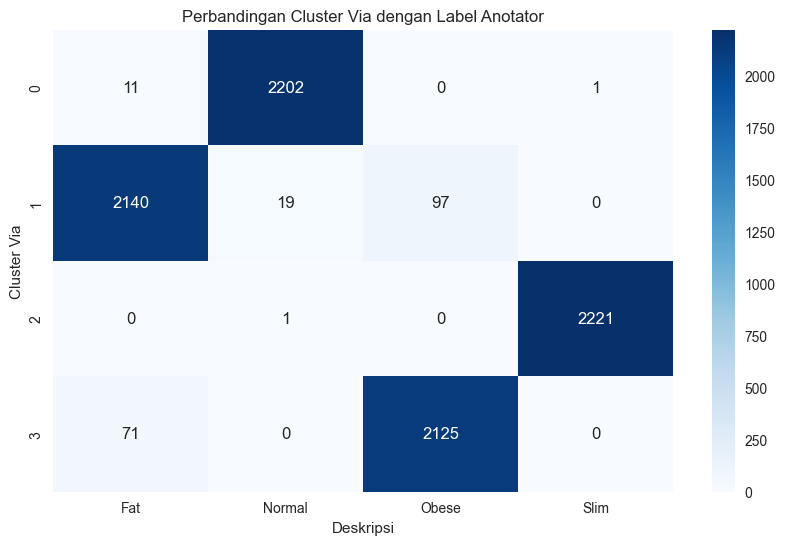

Silhouette Score (K=4): 0.6221
Purity: 0.9775


In [88]:
# Bandingkan dengan label anotator
ct = pd.crosstab(df['cluster_via'], df['deskripsi'])
print(ct)

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Perbandingan Cluster Via dengan Label Anotator')
plt.ylabel('Cluster Via')
plt.xlabel('Deskripsi')
plt.show()

# Hitung metrik evaluasi
from sklearn.metrics import silhouette_score

X_scaled = df_scalling.values
labels = df['cluster_via'].values
silhouette = silhouette_score(X_scaled, labels, sample_size=2000, random_state=0)
purity = np.sum(np.max(ct.values, axis=1)) / np.sum(ct.values)

print(f"Silhouette Score (K={len(np.unique(labels))}): {silhouette:.4f}")
print(f"Purity: {purity:.4f}")

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Nilai K terbaik adalah K=4 baik KElbowVisualizer (Via‑Score) maupun pola pada grafik Elbow mendukung pilihan ini.
2. Visualisasi (scatterplot) dan heatmap menunjukkan bahwa setiap cluster mayoritas berkorespondensi dengan satu label anotator, sehingga clustering K-Means menghasilkan pemisahan yang konsisten dengan anotasi manusia.
3. terdapat kecocokan yang optimal antara hasil clustering dan anotasi manusia.

### Thank you :)